In [34]:
!pip install rich


[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [35]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import tensorflow as tf
from tensorflow.keras import Model, Input, optimizers
from tensorflow.keras.layers import Conv1D, Dense, Dropout, SpatialDropout1D, LayerNormalization, Activation, Add, Flatten
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.preprocessing import StandardScaler
import os
import random

# --- 1. Configuration & Reproducibility ---
# Best Parameters from Optuna Trial 10
BEST_PARAMS = {
    'lookback': 30,
    'filters': 32,
    'kernel_size': 3,
    'dropout': 0.416,
    'num_stacks': 1,
    'dilations': (1, 2, 4),
    'lr': 0.005,
    'batch_size': 32,
    'epochs': 50,
    'patience': 6
}

CSV_PATH = "ALL_MERGED.csv"  # Ensure this file is in your directory
TARGET_COL = "JKSE"
RANDOM_SEED = 1234

print(f"Setting Random Seed: {RANDOM_SEED}")
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)

Setting Random Seed: 1234


In [36]:
# --- 2. Data Loading & Preprocessing ---
def load_and_process_data(csv_path, target_col):
    df = pd.read_csv(csv_path)
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').set_index('Date')
    df = df.ffill().bfill()
    
    # Split Data
    n = len(df)
    test_n = int(np.floor(0.20 * n))
    val_n = int(np.floor(0.10 * (n - test_n)))
    train_n = n - test_n - val_n
    
    train_df = df.iloc[:train_n]
    val_df = df.iloc[train_n:train_n + val_n]
    test_df = df.iloc[train_n + val_n:]
    
    # Scaling
    feature_cols = df.columns.tolist()
    X_scaler = StandardScaler()
    y_scaler = StandardScaler()
    
    X_scaler.fit(train_df[feature_cols])
    y_scaler.fit(train_df[[target_col]])
    
    def scale_df(d):
        return X_scaler.transform(d[feature_cols]), y_scaler.transform(d[[target_col]]).flatten()
    
    X_train_s, y_train_s = scale_df(train_df)
    X_val_s, y_val_s = scale_df(val_df)
    X_test_s, y_test_s = scale_df(test_df)
    
    return (X_train_s, y_train_s, train_df.index), \
           (X_val_s, y_val_s, val_df.index), \
           (X_test_s, y_test_s, test_df.index), \
           y_scaler

(X_train_s, y_train_s, idx_train), \
(X_val_s, y_val_s, idx_val), \
(X_test_s, y_test_s, idx_test), y_scaler = load_and_process_data(CSV_PATH, TARGET_COL)

# Sliding Window Function
def make_windows(X, y, width):
    X_out, y_out, indices = [], [], []
    for i in range(len(X) - width):
        X_out.append(X[i : i + width])
        y_out.append(y[i + width])
        indices.append(i + width) # Keep track of time index
    return np.array(X_out), np.array(y_out), indices

lookback = BEST_PARAMS['lookback']
X_train_w, y_train_w, train_indices = make_windows(X_train_s, y_train_s, lookback)
X_val_w, y_val_w, val_indices = make_windows(X_val_s, y_val_s, lookback)
X_test_w, y_test_w, test_indices = make_windows(X_test_s, y_test_s, lookback)

In [37]:
# --- 3. TCN Model Definition ---
def residual_block(x, filters, kernel_size, dilation_rate, dropout):
    # Dilated Conv 1
    res = x
    x = Conv1D(filters=filters, kernel_size=kernel_size, 
               dilation_rate=dilation_rate, padding='causal', activation='elu')(x)
    x = LayerNormalization()(x)
    x = SpatialDropout1D(dropout)(x)
    
    # Dilated Conv 2
    x = Conv1D(filters=filters, kernel_size=kernel_size, 
               dilation_rate=dilation_rate, padding='causal', activation='elu')(x)
    x = LayerNormalization()(x)
    x = SpatialDropout1D(dropout)(x)
    
    # 1x1 Conv to match dimensions if needed
    if res.shape[-1] != filters:
        res = Conv1D(filters=filters, kernel_size=1, padding='same')(res)
    
    x = Add()([x, res])
    return Activation('elu')(x)

def build_tcn_model(input_shape, params):
    inputs = Input(shape=input_shape)
    x = inputs
    
    # Initial projection
    x = Conv1D(filters=params['filters'], kernel_size=1, padding='causal')(x)
    
    # Stack TCN blocks
    for stack in range(params['num_stacks']):
        for dilation in params['dilations']:
            x = residual_block(x, params['filters'], params['kernel_size'], 
                               dilation, params['dropout'])
    
    # Feature Extraction Layer (The Penultimate Layer for Laplace)
    # We take the last time step only
    x =  tf.keras.layers.Lambda(lambda t: t[:, -1, :])(x)
    
    # Heteroscedastic Output Head: [Mean, Log_Var]
    outputs = Dense(2)(x) 
    
    model = Model(inputs, outputs)
    
    # Heteroscedastic Loss
    def hetero_loss(y_true, y_pred):
        mean = y_pred[:, 0]
        log_var = y_pred[:, 1]
        precision = tf.exp(-log_var)
        return tf.reduce_mean(0.5 * precision * tf.square(y_true - mean) + 0.5 * log_var)
    
    optimizer = optimizers.Adam(learning_rate=params['lr'])
    model.compile(optimizer=optimizer, loss=hetero_loss)
    
    return model

In [38]:
# --- 4. Training ---
print("\n>>> Training TCN with Best Parameters...")
model = build_tcn_model((lookback, X_train_s.shape[1]), BEST_PARAMS)
model.summary()

history = model.fit(
    X_train_w, y_train_w,
    validation_data=(X_val_w, y_val_w),
    epochs=BEST_PARAMS['epochs'],
    batch_size=BEST_PARAMS['batch_size'],
    callbacks=[EarlyStopping(patience=BEST_PARAMS['patience'], restore_best_weights=True)],
    verbose=1
)


>>> Training TCN with Best Parameters...


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 30, 14)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_21 (Conv1D)  │ (None, 30, 32)    │        480 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_22 (Conv1D)  │ (None, 30, 32)    │      3,104 │ conv1d_21[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 32)    │         64 │ conv1d_22[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_… │ (None, 30, 32)    │          0 │ layer_normalizat… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_23 (Conv1D)  │ (None, 30, 32)    │      3,104 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 32)    │         64 │ conv1d_23[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_… │ (None, 30, 32)    │          0 │ layer_normalizat… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 30, 32)    │          0 │ spatial_dropout1… │
│                     │                   │            │ conv1d_21[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_9        │ (None, 30, 32)    │          0 │ add_9[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_24 (Conv1D)  │ (None, 30, 32)    │      3,104 │ activation_9[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 32)    │         64 │ conv1d_24[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_… │ (None, 30, 32)    │          0 │ layer_normalizat… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_25 (Conv1D)  │ (None, 30, 32)    │      3,104 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 32)    │         64 │ conv1d_25[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_… │ (None, 30, 32)    │          0 │ layer_normalizat… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_10 (Add)        │ (None, 30, 32)    │          0 │ spatial_dropout1… │
│                     │                   │            │ activation_9[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_10       │ (None, 30, 32)    │          0 │ add_10[0][0]      │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 19,554 (76.38 KB)

 Trainable params: 19,554 (76.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 8.0448 - val_loss: 1.8082
Epoch 2/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.5538 - val_loss: 1.2919
Epoch 3/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.2051 - val_loss: 0.4040
Epoch 4/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.8671 - val_loss: 0.3043
Epoch 5/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.6831 - val_loss: 0.2108
Epoch 6/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.4117 - val_loss: 0.0162
Epoch 7/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1837 - val_loss: -0.1454
Epoch 8/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0279 - val_loss: -0.3589
Epoch 9/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: -0.1361 - val_loss: -0.2486
Epoch 10/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: -0.2807 - val_loss: -0.4777
Epoch 11/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: -0.3644 - val_loss: -0.4552
Epoch 12/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: -0.

In [ ]:
# --- 5. Last Layer Laplace Approximation (LLLA) ---
print("\n>>> Extracting Features for Laplace Approximation...")

# Create Feature Extractor (Phi Model)
# We want the output of the Lambda layer (index -2), which has shape (Batch, Filters)
phi_model = Model(inputs=model.input, outputs=model.layers[-2].output)

# Extract Features (Phi)
phi_train = phi_model.predict(X_train_w, verbose=0)
phi_test = phi_model.predict(X_test_w, verbose=0)

print(f"Feature shape (Phi): {phi_train.shape}") # Should be (N, 32) based on best params

# Estimate Residual Variance (Sigma_n^2)
y_pred_train = model.predict(X_train_w, verbose=0)
mu_train = y_pred_train[:, 0]
residuals = y_train_w - mu_train
sigma_n2 = np.mean(residuals**2) 
print(f"Estimated Noise Variance (sigma_n^2): {sigma_n2:.4f}")

# Construct Hessian Matrix
# H = (1/sigma^2) * (Phi^T @ Phi) + Prior
N, H_dim = phi_train.shape
# Add bias term column of ones
Phi_train_aug = np.hstack([phi_train, np.ones((N, 1))]) 

lambda_prior = 25
# Full Hessian Calculation
H_full = (1.0 / sigma_n2) * (Phi_train_aug.T @ Phi_train_aug) + np.eye(H_dim + 1) * lambda_prior

# Invert for Covariance (Uncertainty)
Sigma_post = np.linalg.inv(H_full)


>>> Extracting Features for Laplace Approximation...
Feature shape (Phi): (2602, 32)
Estimated Noise Variance (sigma_n^2): 0.0050



>>> Generating Hessian Visualizations...


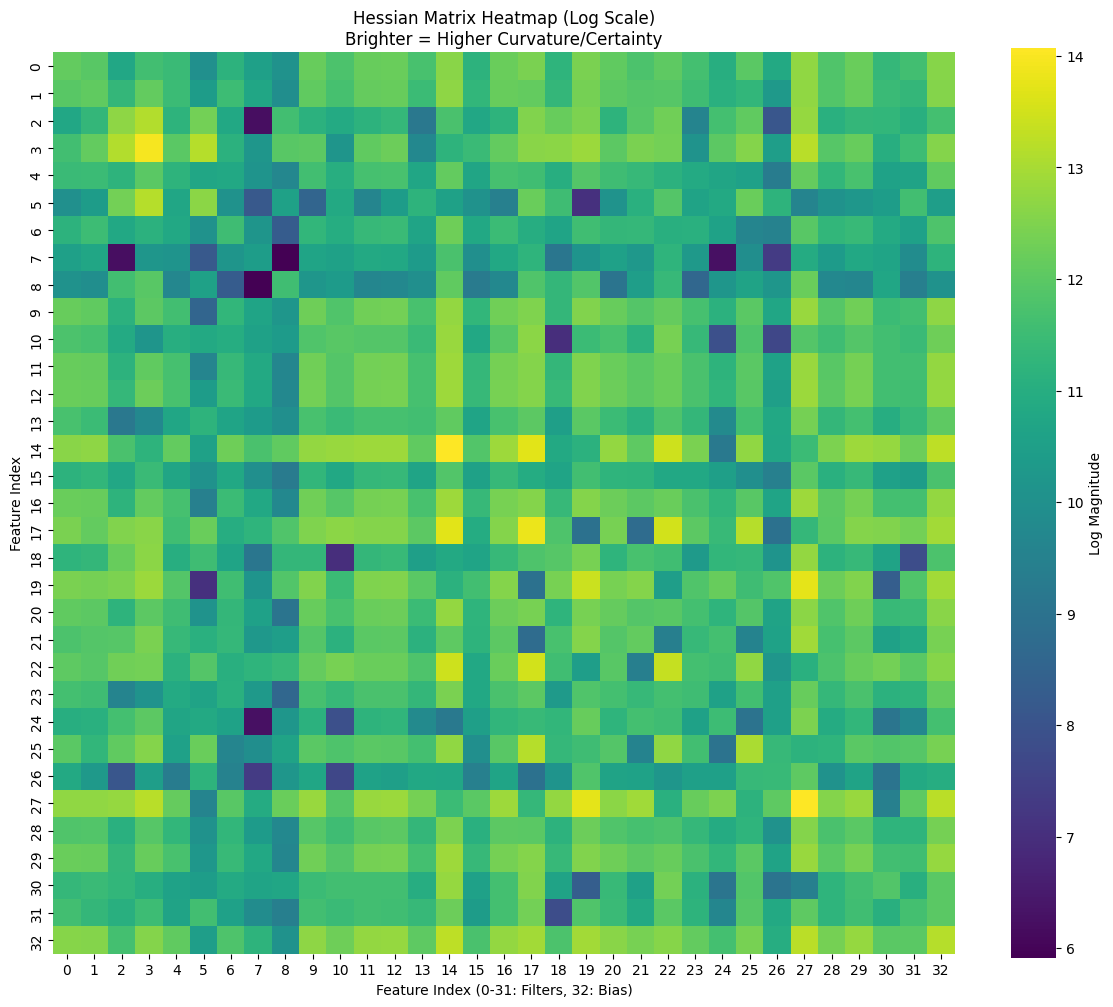

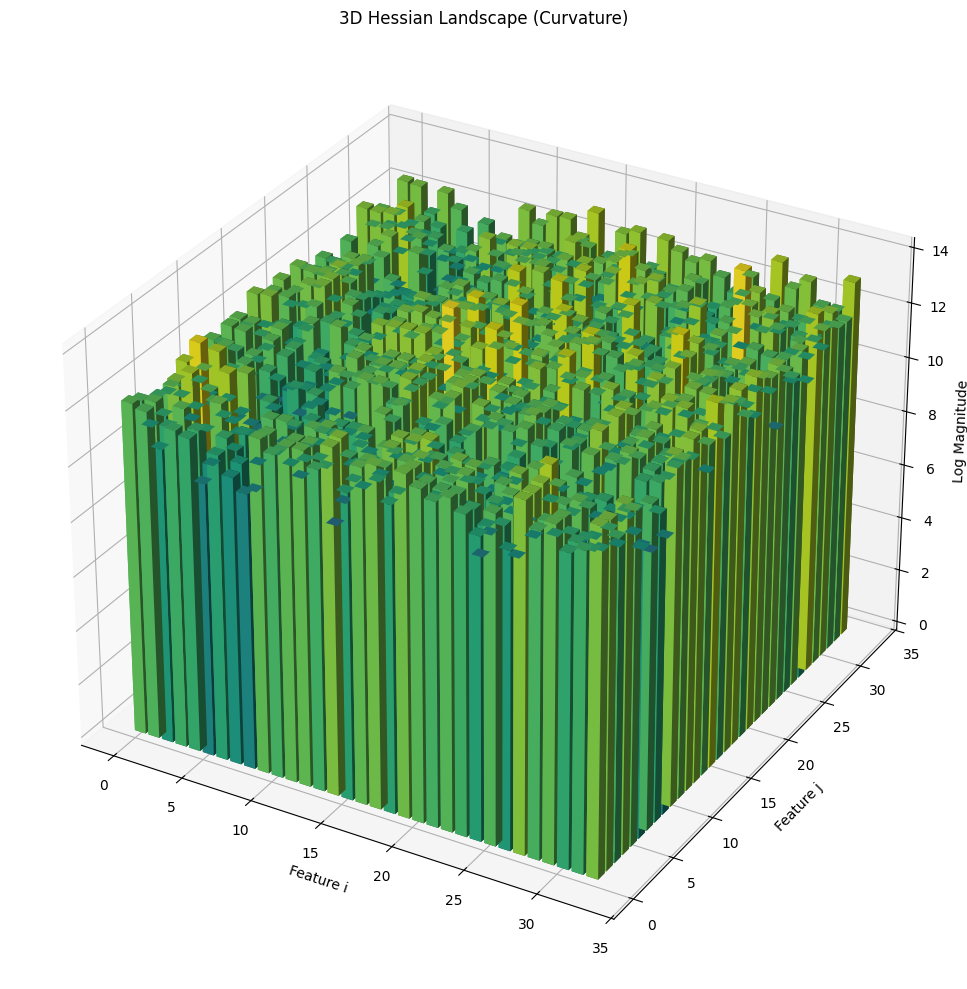

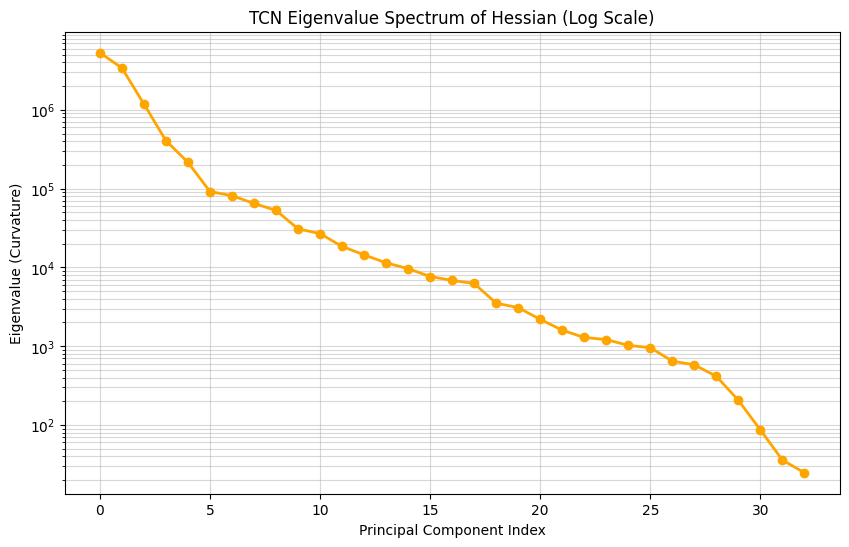

In [40]:
# --- 6. Visualization: The Hessian Matrix ---
print("\n>>> Generating Hessian Visualizations...")

# A. 2D Heatmap of the Hessian
plt.figure(figsize=(12, 10))
sns.heatmap(np.log1p(np.abs(H_full)), cmap="viridis", square=True, cbar_kws={'label': 'Log Magnitude'})
plt.title("Hessian Matrix Heatmap (Log Scale)\nBrighter = Higher Curvature/Certainty")
plt.xlabel("Feature Index (0-31: Filters, 32: Bias)")
plt.ylabel("Feature Index")
plt.tight_layout()
plt.show()

# B. 3D "Cityscape" Plot of the Hessian
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Coordinates
x_range = np.arange(H_full.shape[0])
y_range = np.arange(H_full.shape[1])
X, Y = np.meshgrid(x_range, y_range)
x, y = X.flatten(), Y.flatten()
z = np.zeros_like(x)

# Dimensions
dx = dy = 0.8
# Log scale for height visibility
dz = np.log1p(np.abs(H_full.flatten()))

# Colormap
cmap = plt.cm.viridis
norm = plt.Normalize(dz.min(), dz.max())
colors = cmap(norm(dz))

ax.bar3d(x, y, z, dx, dy, dz, color=colors, shade=True)
ax.set_title("3D Hessian Landscape (Curvature)")
ax.set_xlabel("Feature i")
ax.set_ylabel("Feature j")
ax.set_zlabel("Log Magnitude")
plt.tight_layout()
plt.show()

# C. Eigenvalue Spectrum (Scree Plot)
eigvals = np.linalg.eigvalsh(H_full)
eigvals = np.sort(eigvals)[::-1]

plt.figure(figsize=(10, 6))
plt.plot(eigvals, 'o-', linewidth=2, color='orange')
plt.yscale('log')
plt.title("TCN Eigenvalue Spectrum of Hessian (Log Scale)")
plt.xlabel("Principal Component Index")
plt.ylabel("Eigenvalue (Curvature)")
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

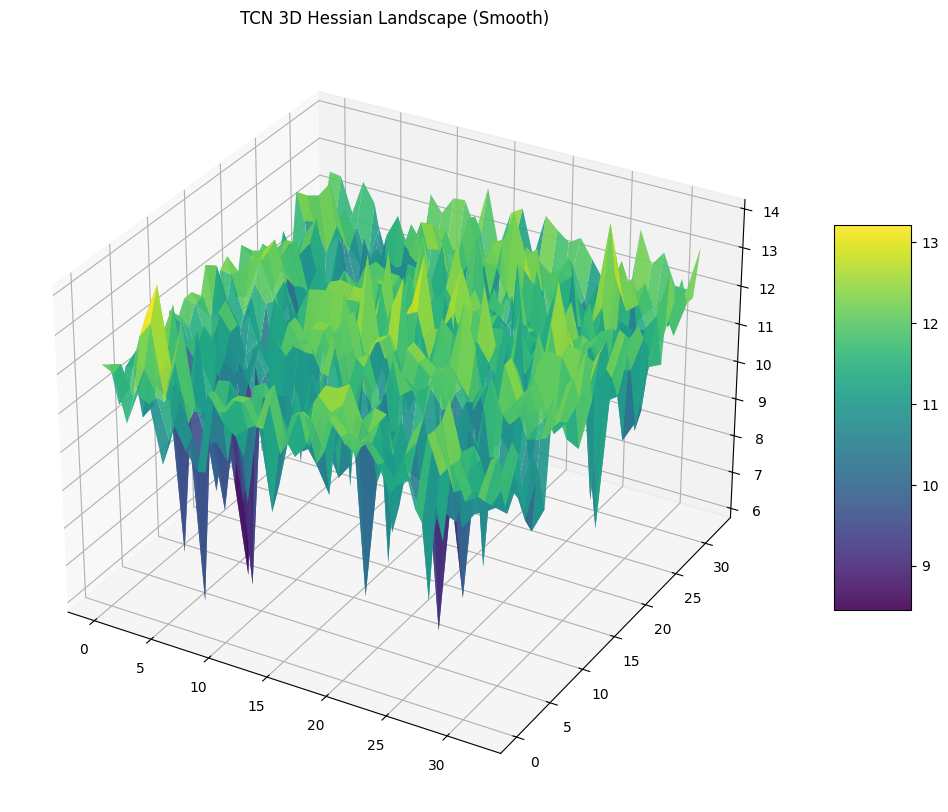

In [41]:
# Static Matplotlib Version (Smooth but not interactable)
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

X, Y = np.meshgrid(np.arange(H_full.shape[0]), np.arange(H_full.shape[1]))
Z = np.log1p(np.abs(H_full))

# 'antialiased=False' makes it look smoother sometimes
surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.9)

ax.set_title("TCN 3D Hessian Landscape (Smooth)")
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.show()

In [42]:
!pip install plotly
!pip install --upgrade nbformat


[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [43]:
import plotly.graph_objects as go

print("\n>>> Generating Interactive 3D Hessian...")

# 1. Prepare Data
# We use the Log Magnitude again so the peaks are visible
z_data = np.log1p(np.abs(H_full)) 

# Create the layout for the axes
x_vals = np.arange(z_data.shape[0]) # Feature Index i
y_vals = np.arange(z_data.shape[1]) # Feature Index j

# 2. Create the Interactive Surface Plot
fig = go.Figure(data=[go.Surface(
    z=z_data,
    x=x_vals,
    y=y_vals,
    colorscale='Viridis',
    contours = {
        "z": {"show": True, "start": 0, "end": np.max(z_data), "size": 0.5, "color":"white"} # Optional contour lines
    }
)])

# 3. Add Labels and Titles
fig.update_layout(
    title='Interactive Hessian Landscape (Log Curvature)',
    autosize=False,
    width=900, height=700,
    scene=dict(
        xaxis_title='Feature Index i',
        yaxis_title='Feature Index j',
        zaxis_title='Log Magnitude (Curvature)',
        aspectratio=dict(x=1, y=1, z=0.7), # Squish Z slightly for better view
        camera=dict(eye=dict(x=1.5, y=1.5, z=1.2)) # Initial camera angle
    ),
    margin=dict(l=65, r=50, b=65, t=90)
)

# 4. Show
fig.show()


>>> Generating Interactive 3D Hessian...


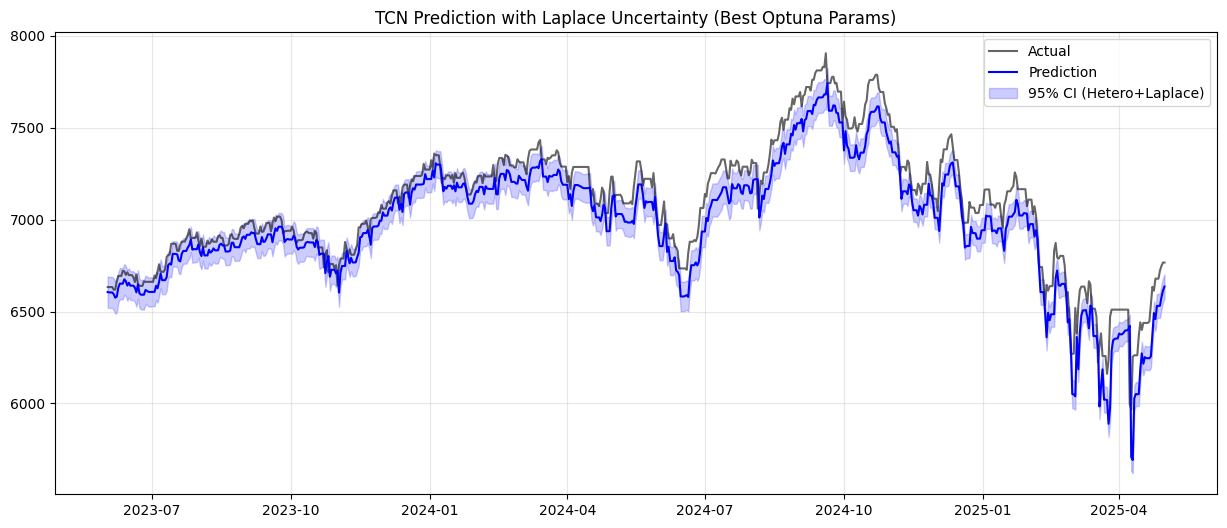

In [44]:
# --- 7. Final Inference with Uncertainty (CORRECTED) ---
# Calculate Aleatoric & Epistemic Uncertainty for Test Set
y_pred_test = model.predict(X_test_w, verbose=0)
mu_test_s = y_pred_test[:, 0]
log_var_test_s = y_pred_test[:, 1]

# Aleatoric (Data noise)
sigma_ale_s = np.sqrt(np.exp(log_var_test_s))

# Epistemic (Model uncertainty via Laplace)
Phi_test_aug = np.hstack([phi_test, np.ones((phi_test.shape[0], 1))])
# variance = diag(Phi * Sigma_post * Phi.T)
var_epi_s = np.sum(Phi_test_aug @ Sigma_post * Phi_test_aug, axis=1)
sigma_epi_s = np.sqrt(var_epi_s)

# Combine
sigma_total_s = np.sqrt(sigma_ale_s**2 + sigma_epi_s**2)

# Inverse Scale to original units
y_mean = y_scaler.mean_[0]
y_std = y_scaler.scale_[0]

mu_test = mu_test_s * y_std + y_mean
sigma_total = sigma_total_s * y_std

# Plot Predictions
plt.figure(figsize=(15, 6))

# --- FIX IS HERE ---
# Use idx_test (which is available) instead of df.index (which is not)
# test_indices are integers relative to the start of the test set
test_dates = idx_test[test_indices] 
# -------------------

plt.plot(test_dates, y_test_w * y_std + y_mean, label="Actual", color="black", alpha=0.6)
plt.plot(test_dates, mu_test, label="Prediction", color="blue")
plt.fill_between(test_dates, 
                 mu_test - 1.96 * sigma_total, 
                 mu_test + 1.96 * sigma_total, 
                 color="blue", alpha=0.2, label="95% CI (Hetero+Laplace)")

plt.title("TCN Prediction with Laplace Uncertainty (Best Optuna Params)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()